# Quantizer Data Analysis

This notebook only reads saved CSV files and does not run any quantizer. You can rerun it to refresh tables and plots without changing the timing measurements. To intentionally collect new timings, run `quantizer_sample_collection.ipynb`.


In [22]:
from __future__ import annotations

import json
import math
import sys
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

SEED = 0
ALPHA = 0.05
POWER = 0.80
TWO_SIDED = True
FWER_SCOPE = "all_metrics"
N_METRICS_FOR_FWER = 3
MHT_CORRECTION_METHOD = "bonferroni"
ANOVA_EFFECT_SCENARIOS = ("two_levels_symmetric", "one_vs_rest")
MIN_INTERESTING_SQNR_BITS_DIFF = 0.10
MIN_INTERESTING_QUANTIZE_SECONDS = 0.1
MIN_INTERESTING_DEQUANTIZE_SECONDS = 0.01

DATA_SOURCE = "llm_weight_blocks"
RESULTS_DIR = ROOT / "results" / "quantizer_sample_size_experiment"
RUN_ID = f"seed{SEED}_{DATA_SOURCE}"
RUN_DIR = RESULTS_DIR / RUN_ID
PILOT_CSV = RUN_DIR / "pilot_experiment.csv"
FINAL_CSV = RUN_DIR / "final_experiment.csv"
REPORT_ASSETS_DIR = ROOT / "report_assets"
REPORT_ASSETS_DIR.mkdir(exist_ok=True)

print(f"Pilot CSV: {PILOT_CSV}")
print(f"Final CSV: {FINAL_CSV}")


Pilot CSV: /home/diego/Documents/master/llm-quantization-benchmarks/results/quantizer_sample_size_experiment/seed0_llm_weight_blocks/pilot_experiment.csv
Final CSV: /home/diego/Documents/master/llm-quantization-benchmarks/results/quantizer_sample_size_experiment/seed0_llm_weight_blocks/final_experiment.csv


In [23]:
from itertools import combinations

from scipy import stats


def normal_quantile(p: float) -> float:
    return float(stats.norm.ppf(float(p)))


def pilot_sample_size_for_sd(confidence: float = 0.95, relative_error: float = 0.25) -> int:
    # Pilot-study approximation: n_pilot ~= 2 * (z_{alpha_n/2} / e_n)^2.
    alpha_n = 1.0 - float(confidence)
    z = normal_quantile(1.0 - alpha_n / 2.0)
    return int(math.ceil(2.0 * (z / float(relative_error)) ** 2))


def paired_t_power(n: int, sd_diff: float, delta: float, alpha: float, two_sided: bool = True) -> float:
    if n < 2 or sd_diff <= 0.0:
        return 0.0
    df = int(n) - 1
    ncp = math.sqrt(float(n)) * float(delta) / float(sd_diff)
    if two_sided:
        tcrit = float(stats.t.ppf(1.0 - alpha / 2.0, df))
        value = float(stats.nct.sf(tcrit, df, ncp) + stats.nct.cdf(-tcrit, df, ncp))
    else:
        tcrit = float(stats.t.ppf(1.0 - alpha, df))
        value = float(stats.nct.sf(tcrit, df, ncp))
    if not math.isfinite(value):
        return 1.0 if ncp > 0.0 else 0.0
    return min(1.0, max(0.0, value))


def paired_sample_size_t(sd_diff: float, delta: float, alpha: float, power: float, two_sided: bool = True) -> int:
    if delta <= 0.0:
        raise ValueError("delta must be positive")
    if sd_diff <= 0.0:
        return 2

    lo = 2
    hi = 2
    while paired_t_power(hi, sd_diff, delta, alpha, two_sided) < power:
        hi *= 2
        if hi > 10_000_000:
            raise RuntimeError("sample-size search exceeded 10,000,000 observations")

    while lo < hi:
        mid = (lo + hi) // 2
        if paired_t_power(mid, sd_diff, delta, alpha, two_sided) >= power:
            hi = mid
        else:
            lo = mid + 1
    return int(lo)


In [24]:
def load_metric_samples_from_experiment_csv(csv_path: Path, metric: str) -> dict[str, np.ndarray]:
    df = pd.read_csv(csv_path)
    if metric not in {"mse", "sqnr_bits", "quantize_seconds", "dequantize_seconds"}:
        raise ValueError(f"unknown metric: {metric}")

    samples = {}
    for method, group in df.sort_values("block_id").groupby("method", sort=False):
        samples[method] = group[metric].to_numpy(dtype=np.float64)
    return samples




def adjusted_alpha_for_comparisons(alpha_family: float, n_comparisons: int, method: str = MHT_CORRECTION_METHOD) -> float:
    if n_comparisons <= 1:
        return float(alpha_family)
    method = str(method).lower()
    if method == "bonferroni":
        return float(alpha_family) / float(n_comparisons)
    if method == "sidak":
        return 1.0 - (1.0 - float(alpha_family)) ** (1.0 / float(n_comparisons))
    raise ValueError(f"unknown MHT correction method: {method}")


def pairwise_alpha_for_scope(n_methods: int, alpha: float) -> tuple[float, int]:
    n_comparisons = math.comb(n_methods, 2) if n_methods >= 2 else 0
    if n_comparisons == 0:
        return float(alpha), 1
    metric_families = int(N_METRICS_FOR_FWER) if FWER_SCOPE == "all_metrics" else 1
    total_planned_comparisons = n_comparisons * metric_families
    return adjusted_alpha_for_comparisons(alpha, total_planned_comparisons), total_planned_comparisons


def planned_comparisons_table(method_names: list[str], metrics: list[str], alpha_family: float = ALPHA) -> pd.DataFrame:
    n_pairwise = math.comb(len(method_names), 2) if len(method_names) >= 2 else 0
    metric_families = len(metrics) if FWER_SCOPE == "all_metrics" else 1
    total_planned_comparisons = n_pairwise * metric_families
    alpha_adjusted = adjusted_alpha_for_comparisons(alpha_family, total_planned_comparisons)
    rows = []
    for metric in metrics:
        for a, b in combinations(method_names, 2):
            rows.append({
                "metric": metric,
                "comparison": f"{a} vs {b}",
                "family_alpha": float(alpha_family),
                "alpha_adjustment_method": MHT_CORRECTION_METHOD,
                "fwer_scope": FWER_SCOPE,
                "n_pairwise_algorithm_comparisons": int(n_pairwise),
                "n_metric_families_in_correction": int(metric_families),
                "total_planned_comparisons": int(total_planned_comparisons),
                "adjusted_alpha": float(alpha_adjusted),
            })
    return pd.DataFrame(rows)


In [25]:
def sample_matrix(samples_by_method: dict[str, np.ndarray]) -> tuple[list[str], np.ndarray]:
    names = list(samples_by_method)
    values = [np.asarray(samples_by_method[name], dtype=np.float64) for name in names]
    if not values:
        raise ValueError("samples_by_method cannot be empty")
    first_shape = values[0].shape
    if any(value.shape != first_shape for value in values):
        raise ValueError("all paired sample arrays must have the same shape")
    return names, np.column_stack(values)



def anova_tau_vector(n_groups: int, delta: float, scenario: str) -> np.ndarray:
    n_groups = int(n_groups)
    delta = float(delta)
    if n_groups < 2:
        raise ValueError("ANOVA needs at least two groups")
    scenario = str(scenario)
    if scenario == "two_levels_symmetric":
        tau = np.zeros(n_groups, dtype=np.float64)
        tau[0] = -delta / 2.0
        tau[1] = delta / 2.0
        return tau
    if scenario == "one_vs_rest":
        tau = np.full(n_groups, delta / float(n_groups), dtype=np.float64)
        tau[0] = -delta * float(n_groups - 1) / float(n_groups)
        return tau
    raise ValueError(f"unknown ANOVA effect scenario: {scenario}")


def one_way_anova_within_variance(samples_by_method: dict[str, np.ndarray]) -> float:
    _, y = sample_matrix(samples_by_method)
    n_blocks, n_groups = y.shape
    if n_blocks < 2:
        return float("nan")
    group_means = np.mean(y, axis=0, keepdims=True)
    residuals = y - group_means
    ss_within = float(np.sum(residuals ** 2))
    df_within = int(n_groups * (n_blocks - 1))
    return ss_within / float(df_within) if df_within > 0 else float("nan")


In [26]:
def anova_global_power(n_per_group: int, n_groups: int, sigma: float, delta: float, alpha: float, scenario: str) -> float:
    n_per_group = int(n_per_group)
    n_groups = int(n_groups)
    sigma = float(sigma)
    if n_per_group < 2 or n_groups < 2 or sigma <= 0.0:
        return 0.0
    tau = anova_tau_vector(n_groups, delta, scenario)
    df1 = n_groups - 1
    df2 = n_groups * (n_per_group - 1)
    noncentrality = float(n_per_group) * float(np.sum(tau ** 2)) / float(sigma ** 2)
    fcrit = float(stats.f.ppf(1.0 - float(alpha), df1, df2))
    power_value = float(stats.ncf.sf(fcrit, df1, df2, noncentrality))
    if not math.isfinite(power_value):
        return 0.0
    return min(1.0, max(0.0, power_value))


def anova_global_sample_size(n_groups: int, sigma: float, delta: float, alpha: float, power: float, scenario: str) -> int:
    if delta <= 0.0:
        raise ValueError("delta must be positive")
    if sigma <= 0.0:
        return 2
    lo = 2
    hi = 2
    while anova_global_power(hi, n_groups, sigma, delta, alpha, scenario) < power:
        hi *= 2
        if hi > 10_000_000:
            raise RuntimeError("ANOVA sample-size search exceeded 10,000,000 observations per group")
    while lo < hi:
        mid = (lo + hi) // 2
        if anova_global_power(mid, n_groups, sigma, delta, alpha, scenario) >= power:
            hi = mid
        else:
            lo = mid + 1
    return int(lo)


In [27]:
def anova_sample_size_table_from_samples(
    samples_by_method: dict[str, np.ndarray],
    alpha: float,
    power: float,
    delta: float,
    metric: str,
    sample_unit: str,
    scenarios=ANOVA_EFFECT_SCENARIOS,
) -> pd.DataFrame:
    names, y = sample_matrix(samples_by_method)
    n_groups = len(names)
    within_variance = one_way_anova_within_variance(samples_by_method)
    sigma = math.sqrt(within_variance) if math.isfinite(within_variance) and within_variance >= 0.0 else float("nan")
    rows = []
    for scenario in scenarios:
        tau = anova_tau_vector(n_groups, delta, scenario)
        required_n = anova_global_sample_size(n_groups, sigma, delta, alpha, power, scenario)
        rows.append({
            "metric": metric,
            "sample_unit": sample_unit,
            "test": "one_way_anova_global_f_test",
            "scenario": scenario,
            "n_algorithms": int(n_groups),
            "pilot_samples_per_algorithm": int(y.shape[0]),
            "minimum_interesting_difference": float(delta),
            "family_alpha": float(alpha),
            "power": float(power),
            "pilot_within_variance": float(within_variance),
            "pilot_within_sd": float(sigma),
            "tau_vector": json.dumps(tau.astype(float).tolist(), separators=(",", ":")),
            "sum_tau_squared": float(np.sum(tau ** 2)),
            "between_variance_tau": float(np.var(tau, ddof=1)),
            "required_n_per_algorithm": int(required_n),
            "achieved_power_at_required_n": anova_global_power(required_n, n_groups, sigma, delta, alpha, scenario),
        })
    return pd.DataFrame(rows).sort_values("required_n_per_algorithm", ascending=False).reset_index(drop=True)


def required_anova_n_from_table(table: pd.DataFrame) -> int:
    if len(table) == 0:
        raise ValueError("empty ANOVA sample-size table")
    return int(table["required_n_per_algorithm"].max())


def add_anova_planned_power(table: pd.DataFrame, planned_n: int) -> pd.DataFrame:
    out = table.copy()
    out["planned_n_per_algorithm"] = int(planned_n)
    out["achieved_power_at_planned_n"] = [
        anova_global_power(
            int(planned_n),
            int(row.n_algorithms),
            float(row.pilot_within_sd),
            float(row.minimum_interesting_difference),
            float(row.family_alpha),
            str(row.scenario),
        )
        for row in out.itertuples(index=False)
    ]
    out["underpowered_at_planned_n"] = out["achieved_power_at_planned_n"] < out["power"]
    return out


In [28]:
def sample_size_table_from_samples(samples_by_method: dict[str, np.ndarray], alpha: float, power: float, delta: float, metric: str, sample_unit: str):
    names = list(samples_by_method)
    n_comparisons = math.comb(len(names), 2) if len(names) >= 2 else 0
    alpha_pair, total_planned_comparisons = pairwise_alpha_for_scope(len(names), alpha)
    rows = []
    for a, b in combinations(names, 2):
        a_values = np.asarray(samples_by_method[a], dtype=np.float64)
        b_values = np.asarray(samples_by_method[b], dtype=np.float64)
        if a_values.shape != b_values.shape:
            raise ValueError(f"paired samples for {a} and {b} must have the same shape")
        diff = a_values - b_values
        sd_diff = float(np.std(diff, ddof=1))
        mean_diff = float(np.mean(diff))
        required_n = paired_sample_size_t(sd_diff, delta, alpha_pair, power, TWO_SIDED)
        rows.append({
            "metric": metric,
            "sample_unit": sample_unit,
            "comparison": f"{a} vs {b}",
            "pilot_mean_diff": mean_diff,
            "pilot_sd_diff": sd_diff,
            "minimum_interesting_difference": float(delta),
            "delta": float(delta),
            "family_alpha": float(alpha),
            "alpha_adjustment_method": MHT_CORRECTION_METHOD,
            "adjusted_alpha": float(alpha_pair),
            "alpha_pair": float(alpha_pair),
            "fwer_scope": FWER_SCOPE,
            "total_planned_comparisons": int(total_planned_comparisons),
            "power": float(power),
            "required_n": required_n,
            "achieved_power_at_required_n": paired_t_power(required_n, sd_diff, delta, alpha_pair, TWO_SIDED),
        })
    if pd is not None:
        return pd.DataFrame(rows).sort_values("required_n", ascending=False).reset_index(drop=True)
    return rows


def required_n_from_table(table) -> int:
    if pd is not None and hasattr(table, "__len__") and len(table) > 0:
        return int(table["required_n"].max())
    return max(row["required_n"] for row in table)


def add_planned_power(table, planned_n: int):
    if pd is None:
        rows = []
        for row in table:
            row = dict(row)
            planned_power = paired_t_power(
                int(planned_n),
                float(row["pilot_sd_diff"]),
                float(row["delta"]),
                float(row["alpha_pair"]),
                TWO_SIDED,
            )
            row["planned_n"] = int(planned_n)
            row["achieved_power_at_planned_n"] = planned_power
            row["underpowered_at_planned_n"] = bool(planned_power < float(row["power"]))
            rows.append(row)
        return rows

    out = table.copy()
    out["planned_n"] = int(planned_n)
    out["achieved_power_at_planned_n"] = [
        paired_t_power(
            int(planned_n),
            float(row.pilot_sd_diff),
            float(row.delta),
            float(row.alpha_pair),
            TWO_SIDED,
        )
        for row in out.itertuples(index=False)
    ]
    out["underpowered_at_planned_n"] = out["achieved_power_at_planned_n"] < out["power"]
    return out


In [29]:
def metric_summary_from_values(values: np.ndarray, confidence: float = 0.95) -> dict:
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]
    n = int(values.size)
    if n == 0:
        return {
            "n": 0,
            "mean": float("nan"),
            "std_dev": float("nan"),
            "variance": float("nan"),
            "std_error": float("nan"),
            "coefficient_of_variation": float("nan"),
            "ci_level": confidence,
            "ci_low": float("nan"),
            "ci_high": float("nan"),
            "median": float("nan"),
            "q25": float("nan"),
            "q75": float("nan"),
            "min": float("nan"),
            "max": float("nan"),
        }
    mean = float(np.mean(values))
    std_dev = float(np.std(values, ddof=1)) if n > 1 else 0.0
    variance = float(np.var(values, ddof=1)) if n > 1 else 0.0
    std_error = float(std_dev / math.sqrt(n)) if n > 1 else 0.0
    coefficient_of_variation = float(std_dev / abs(mean)) if mean != 0.0 else float("nan")
    if n > 1:
        alpha = 1.0 - confidence
        tcrit = float(stats.t.ppf(1.0 - alpha / 2.0, n - 1))
        ci_low = mean - tcrit * std_error
        ci_high = mean + tcrit * std_error
    else:
        ci_low = mean
        ci_high = mean
    return {
        "n": n,
        "mean": mean,
        "std_dev": std_dev,
        "variance": variance,
        "std_error": std_error,
        "coefficient_of_variation": coefficient_of_variation,
        "ci_level": confidence,
        "ci_low": float(ci_low),
        "ci_high": float(ci_high),
        "median": float(np.median(values)),
        "q25": float(np.quantile(values, 0.25)),
        "q75": float(np.quantile(values, 0.75)),
        "min": float(np.min(values)),
        "max": float(np.max(values)),
    }


def final_data_statistics_from_csv(csv_path: Path, confidence: float = 0.95) -> pd.DataFrame:
    rows = []
    metrics = [
        ("mse", "lower"),
        ("sqnr_bits", "higher"),
        ("quantize_seconds", "lower"),
        ("dequantize_seconds", "lower"),
    ]
    for metric, better_direction in metrics:
        samples = load_metric_samples_from_experiment_csv(csv_path, metric)
        for method, values in samples.items():
            row = {
                "metric": metric,
                "method": method,
                "better_direction": better_direction,
            }
            row.update(metric_summary_from_values(values, confidence=confidence))
            rows.append(row)
    return pd.DataFrame(rows).sort_values(["metric", "mean"], ascending=[True, True]).reset_index(drop=True)


In [30]:
def plot_metric_boxplots_with_ci(csv_path: Path, statistics_table: pd.DataFrame):
    metric_specs = [
        ("mse", "MSE", "lower is better"),
        ("sqnr_bits", "SQNR bits", "higher is better"),
        ("quantize_seconds", "Quantize seconds", "lower is better"),
        ("dequantize_seconds", "Dequantize seconds", "lower is better"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.reshape(-1)

    for ax, (metric, title, direction) in zip(axes, metric_specs):
        samples = load_metric_samples_from_experiment_csv(csv_path, metric)
        methods = list(samples)
        values = [np.asarray(samples[method], dtype=np.float64) for method in methods]
        positions = np.arange(1, len(methods) + 1)

        ax.boxplot(values, positions=positions, tick_labels=methods, showfliers=True)
        metric_stats = statistics_table[statistics_table["metric"] == metric].set_index("method").loc[methods]
        means = metric_stats["mean"].to_numpy(dtype=np.float64)
        ci_low = metric_stats["ci_low"].to_numpy(dtype=np.float64)
        ci_high = metric_stats["ci_high"].to_numpy(dtype=np.float64)
        yerr = np.vstack([means - ci_low, ci_high - means])
        ax.errorbar(
            positions,
            means,
            yerr=yerr,
            fmt="o",
            color="black",
            ecolor="black",
            elinewidth=1.2,
            capsize=4,
            label="mean 95% CI",
        )
        ax.set_title(f"{title} ({direction})")
        ax.set_ylabel(title)
        ax.tick_params(axis="x", labelrotation=20)
        ax.grid(axis="y", alpha=0.25)
        ax.legend(loc="best")

    fig.tight_layout()
    return fig


In [31]:
def plot_metric_distributions_with_normal_reference(csv_path: Path):
    metric_specs = [
        ("mse", "MSE", "lower is better"),
        ("sqnr_bits", "SQNR bits", "higher is better"),
        ("quantize_seconds", "Quantize seconds", "lower is better"),
        ("dequantize_seconds", "Dequantize seconds", "lower is better"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.reshape(-1)

    for ax, (metric, title, direction) in zip(axes, metric_specs):
        samples = load_metric_samples_from_experiment_csv(csv_path, metric)
        colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])

        for idx, (method, raw_values) in enumerate(samples.items()):
            values = np.asarray(raw_values, dtype=np.float64)
            values = values[np.isfinite(values)]
            if values.size == 0:
                continue

            color = colors[idx % len(colors)] if colors else None
            bins = "auto" if values.size >= 10 else max(3, min(8, values.size))
            ax.hist(
                values,
                bins=bins,
                density=True,
                alpha=0.28,
                edgecolor=color,
                linewidth=0.8,
                color=color,
                label=f"{method} histogram",
            )

            mean = float(np.mean(values))
            std = float(np.std(values, ddof=1)) if values.size > 1 else 0.0
            if math.isfinite(std) and std > 0.0:
                x_low, x_high = np.quantile(values, [0.001, 0.999]) if values.size > 5 else (np.min(values), np.max(values))
                x_low = min(float(x_low), mean - 3.0 * std)
                x_high = max(float(x_high), mean + 3.0 * std)
                if x_high > x_low:
                    x_grid = np.linspace(x_low, x_high, 300)
                    ax.plot(
                        x_grid,
                        stats.norm.pdf(x_grid, loc=mean, scale=std),
                        linestyle="--",
                        linewidth=1.1,
                        color=color,
                        label=f"{method} fitted normal",
                    )

        ax.set_title(f"{title} distribution ({direction})")
        ax.set_xlabel(title)
        ax.set_ylabel("Density")
        ax.grid(axis="y", alpha=0.25)
        ax.legend(loc="best", fontsize=8)

    fig.tight_layout()
    return fig


In [32]:
def repeated_measures_residuals(samples_by_method: dict[str, np.ndarray]) -> np.ndarray:
    _, y = sample_matrix(samples_by_method)
    grand = np.mean(y)
    subject_means = np.mean(y, axis=1, keepdims=True)
    method_means = np.mean(y, axis=0, keepdims=True)
    residuals = y - subject_means - method_means + grand
    return residuals.reshape(-1)


def safe_shapiro(values: np.ndarray) -> tuple[float, float, str]:
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]
    if values.size < 3:
        return float("nan"), float("nan"), "not_enough_values"
    if np.allclose(values, values[0]):
        return float("nan"), float("nan"), "constant_values"
    note = "ok"
    if values.size > 5000:
        # scipy warns that W is valid but p-value is less reliable above 5000 observations.
        values = values[:5000]
        note = "first_5000_values"
    stat, p_value = stats.shapiro(values)
    return float(stat), float(p_value), note


def anova_assumption_checks(metric_samples: dict[str, dict[str, np.ndarray]]) -> pd.DataFrame:
    rows = []
    for metric, spec in metric_samples.items():
        samples = spec["samples"]
        _, y = sample_matrix(samples)
        residuals = repeated_measures_residuals(samples)
        shapiro_stat, shapiro_p, shapiro_note = safe_shapiro(residuals)
        rows.append({
            "metric": metric,
            "sample_unit": spec["sample_unit"],
            "assumption": "normality_of_rm_anova_residuals",
            "test": "shapiro_wilk",
            "statistic": shapiro_stat,
            "p_value": shapiro_p,
            "alpha": float(ALPHA),
            "passes_alpha": bool(shapiro_p >= ALPHA) if math.isfinite(shapiro_p) else None,
            "n_blocks": int(y.shape[0]),
            "n_algorithms": int(y.shape[1]),
            "note": shapiro_note,
        })
    return pd.DataFrame(rows)


In [33]:
def repeated_measures_anova(samples_by_method: dict[str, np.ndarray], metric: str, sample_unit: str) -> dict:
    names, y = sample_matrix(samples_by_method)
    n_subjects, n_methods = y.shape
    grand = float(np.mean(y))
    subject_means = np.mean(y, axis=1)
    method_means = np.mean(y, axis=0)
    ss_total = float(np.sum((y - grand) ** 2))
    ss_subject = float(n_methods * np.sum((subject_means - grand) ** 2))
    ss_method = float(n_subjects * np.sum((method_means - grand) ** 2))
    ss_error = max(0.0, ss_total - ss_subject - ss_method)
    df_method = n_methods - 1
    df_error = (n_subjects - 1) * (n_methods - 1)
    ms_method = ss_method / df_method if df_method > 0 else float("nan")
    ms_error = ss_error / df_error if df_error > 0 else float("nan")
    f_stat = ms_method / ms_error if ms_error > 0 else float("inf")
    p_value = float(stats.f.sf(f_stat, df_method, df_error)) if math.isfinite(f_stat) else 0.0
    return {
        "metric": metric,
        "sample_unit": sample_unit,
        "test": "repeated_measures_anova",
        "n_blocks": int(n_subjects),
        "n_algorithms": int(n_methods),
        "statistic": float(f_stat),
        "df1": int(df_method),
        "df2": int(df_error),
        "p_value": p_value,
    }


In [34]:
def global_multiple_sample_tests(metric_samples: dict[str, dict[str, np.ndarray]]):
    rows = []
    for metric, spec in metric_samples.items():
        samples = spec["samples"]
        sample_unit = spec["sample_unit"]
        rows.append(repeated_measures_anova(samples, metric, sample_unit))
    table = pd.DataFrame(rows) if pd is not None else rows
    if pd is not None:
        n_metric_tests = len(metric_samples)
        table["p_bonferroni_all_metrics"] = np.minimum(table["p_value"] * n_metric_tests, 1.0)
        table["reject_at_alpha"] = table["p_bonferroni_all_metrics"] < ALPHA
    return table


In [35]:
def posthoc_pairwise_table(metric_samples: dict[str, dict[str, np.ndarray]]):
    rows = []
    total_planned = 0
    for spec in metric_samples.values():
        total_planned += math.comb(len(spec["samples"]), 2)
    if FWER_SCOPE == "per_metric":
        total_planned = None

    for metric, spec in metric_samples.items():
        samples = spec["samples"]
        higher_is_better = bool(spec["higher_is_better"])
        names = list(samples)
        alpha_pair, scoped_total = pairwise_alpha_for_scope(len(names), ALPHA)
        correction_total = scoped_total if total_planned is None else total_planned
        for a, b in combinations(names, 2):
            a_values = np.asarray(samples[a], dtype=np.float64)
            b_values = np.asarray(samples[b], dtype=np.float64)
            diff = a_values - b_values
            t_stat, p_value = stats.ttest_rel(a_values, b_values)
            mean_diff = float(np.mean(diff))
            if mean_diff == 0.0:
                better = "tie"
            elif higher_is_better:
                better = a if mean_diff > 0.0 else b
            else:
                better = a if mean_diff < 0.0 else b
            rows.append({
                "metric": metric,
                "comparison": f"{a} vs {b}",
                "mean_diff_a_minus_b": mean_diff,
                "sd_diff": float(np.std(diff, ddof=1)),
                "t_statistic": float(t_stat),
                "p_value": float(p_value),
                "p_bonferroni": min(float(p_value) * correction_total, 1.0),
                "alpha_pair": float(alpha_pair),
                "fwer_scope": FWER_SCOPE,
                "total_planned_comparisons": int(correction_total),
                "significant": bool(float(p_value) < alpha_pair),
                "better_if_significant": better,
            })
    table = pd.DataFrame(rows) if pd is not None else rows
    if pd is not None:
        return table.sort_values(["metric", "p_bonferroni"]).reset_index(drop=True)
    return table


In [36]:
def normality_progression_candidate_ns(n_blocks: int) -> list[int]:
    base = [
        5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 90, 100, 125, 150, 175, 200,
        250, 300, 400, 500, 750, 1000, 1250, 1500, 1750, 2000,
    ]
    values = [n for n in base if 3 <= n <= int(n_blocks)]
    if int(n_blocks) not in values:
        values.append(int(n_blocks))
    return sorted(set(values))


def normality_progression_table(metric_samples: dict[str, dict[str, np.ndarray]], alpha: float = ALPHA) -> pd.DataFrame:
    rows = []
    for metric, spec in metric_samples.items():
        samples = spec["samples"]
        names, y = sample_matrix(samples)
        for n_blocks in normality_progression_candidate_ns(y.shape[0]):
            prefix_samples = {name: y[:n_blocks, idx] for idx, name in enumerate(names)}
            residuals = repeated_measures_residuals(prefix_samples)
            statistic, p_value, note = safe_shapiro(residuals)
            rows.append({
                "metric": metric,
                "sample_unit": spec["sample_unit"],
                "n_blocks": int(n_blocks),
                "n_residuals": int(residuals.size),
                "test": "shapiro_wilk",
                "statistic": statistic,
                "p_value": p_value,
                "alpha": float(alpha),
                "passes_alpha": bool(p_value >= alpha) if math.isfinite(p_value) else None,
                "note": note,
            })
    return pd.DataFrame(rows)


def normality_progression_summary(progress_table: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for metric, group in progress_table.groupby("metric", sort=False):
        group = group.sort_values("n_blocks")
        passing = group[group["passes_alpha"].eq(True)]
        full_row = group.iloc[-1]
        rows.append({
            "metric": metric,
            "sample_unit": full_row["sample_unit"],
            "first_passing_n": int(passing.iloc[0]["n_blocks"]) if not passing.empty else float("nan"),
            "largest_passing_n": int(passing.iloc[-1]["n_blocks"]) if not passing.empty else float("nan"),
            "full_n": int(full_row["n_blocks"]),
            "full_n_p_value": float(full_row["p_value"]),
            "alpha": float(full_row["alpha"]),
            "passes_at_full_n": bool(full_row["passes_alpha"]),
        })
    return pd.DataFrame(rows)


def plot_normality_progression(progress_table: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(11, 6))
    for metric, group in progress_table.groupby("metric", sort=False):
        group = group.sort_values("n_blocks")
        ax.plot(group["n_blocks"], group["p_value"], marker="o", linewidth=1.6, label=metric)
    alpha_value = float(progress_table["alpha"].iloc[0]) if len(progress_table) else ALPHA
    ax.axhline(alpha_value, color="black", linestyle="--", linewidth=1.2, label=f"alpha = {alpha_value:g}")
    ax.set_xlabel("Number of paired blocks")
    ax.set_ylabel("Shapiro-Wilk p-value")
    ax.set_title("Residual normality check as sample size increases")
    ax.set_ylim(bottom=0.0, top=1.0)
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    fig.tight_layout()
    return fig



In [37]:
if not PILOT_CSV.exists() or not FINAL_CSV.exists():
    raise FileNotFoundError("Run quantizer_sample_collection.ipynb first to generate pilot and final CSVs.")

pilot_df = pd.read_csv(PILOT_CSV)
final_df = pd.read_csv(FINAL_CSV)
PILOT_N = int(pilot_df["block_id"].nunique())
EXPERIMENT_N = int(final_df["block_id"].nunique())
TIMING_REPEATS = EXPERIMENT_N
method_names = list(load_metric_samples_from_experiment_csv(FINAL_CSV, "sqnr_bits").keys())
planned_metrics = ["sqnr_bits", "quantize_seconds", "dequantize_seconds"]
planned_comparisons = planned_comparisons_table(method_names, planned_metrics, alpha_family=ALPHA)
alpha_pair, total_pairwise_tests = pairwise_alpha_for_scope(len(method_names), ALPHA)

print(f"Pilot rows: {len(pilot_df)}, blocks: {PILOT_N}, methods: {pilot_df['method'].nunique()}")
print(f"Final rows: {len(final_df)}, blocks: {EXPERIMENT_N}, methods: {final_df['method'].nunique()}")
if "weight_normalization" in final_df:
    print("Weight normalization:", sorted(final_df["weight_normalization"].dropna().unique()))


Pilot rows: 120, blocks: 30, methods: 4
Final rows: 268, blocks: 67, methods: 4
Weight normalization: ['block_rms']


In [38]:
pilot_quality_sqnr_from_csv = load_metric_samples_from_experiment_csv(PILOT_CSV, "sqnr_bits")
pilot_quantize_seconds_from_csv = load_metric_samples_from_experiment_csv(PILOT_CSV, "quantize_seconds")
pilot_dequantize_seconds_from_csv = load_metric_samples_from_experiment_csv(PILOT_CSV, "dequantize_seconds")

sample_size_procedure = pd.DataFrame([
    {"step": 1, "procedure": "Choose ANOVA effect scenarios", "notebook_value": ", ".join(ANOVA_EFFECT_SCENARIOS)},
    {"step": 2, "procedure": "Estimate within variance from the pilot data", "notebook_value": "one-way ANOVA within-group residual variance for each metric"},
    {"step": 3, "procedure": "Calculate global ANOVA F-test power", "notebook_value": "noncentral F distribution with df1=a-1 and df2=a(n-1)"},
    {"step": 4, "procedure": "Find smallest n per algorithm reaching target power", "notebook_value": f"alpha={ALPHA}, power={POWER}"},
    {"step": 5, "procedure": "Use the largest required sample size", "notebook_value": "one shared final n across metrics and ANOVA scenarios"},
])

quality_anova_sample_size_table = anova_sample_size_table_from_samples(
    pilot_quality_sqnr_from_csv, alpha=ALPHA, power=POWER,
    delta=MIN_INTERESTING_SQNR_BITS_DIFF, metric="sqnr_bits", sample_unit="vectors")
quantize_time_anova_sample_size_table = anova_sample_size_table_from_samples(
    pilot_quantize_seconds_from_csv, alpha=ALPHA, power=POWER,
    delta=MIN_INTERESTING_QUANTIZE_SECONDS, metric="quantize_seconds", sample_unit="timing_repeats")
dequantize_time_anova_sample_size_table = anova_sample_size_table_from_samples(
    pilot_dequantize_seconds_from_csv, alpha=ALPHA, power=POWER,
    delta=MIN_INTERESTING_DEQUANTIZE_SECONDS, metric="dequantize_seconds", sample_unit="timing_repeats")

REQUIRED_QUALITY_N = required_anova_n_from_table(quality_anova_sample_size_table)
REQUIRED_QUANTIZE_REPEATS = required_anova_n_from_table(quantize_time_anova_sample_size_table)
REQUIRED_DEQUANTIZE_REPEATS = required_anova_n_from_table(dequantize_time_anova_sample_size_table)

quality_anova_sample_size_table = add_anova_planned_power(quality_anova_sample_size_table, EXPERIMENT_N)
quantize_time_anova_sample_size_table = add_anova_planned_power(quantize_time_anova_sample_size_table, TIMING_REPEATS)
dequantize_time_anova_sample_size_table = add_anova_planned_power(dequantize_time_anova_sample_size_table, TIMING_REPEATS)
anova_sample_size_table = pd.concat([
    quality_anova_sample_size_table,
    quantize_time_anova_sample_size_table,
    dequantize_time_anova_sample_size_table,
], ignore_index=True)

sample_size_summary = pd.DataFrame([
    {"metric": "sqnr_bits", "sample_unit": "vectors", "pilot_samples_per_algorithm": PILOT_N, "required_samples_per_algorithm": REQUIRED_QUALITY_N, "planned_samples_per_algorithm": EXPERIMENT_N, "minimum_interesting_difference": MIN_INTERESTING_SQNR_BITS_DIFF, "family_alpha": ALPHA, "power": POWER, "calculation": "anova_global_f_test"},
    {"metric": "quantize_seconds", "sample_unit": "timing_repeats", "pilot_samples_per_algorithm": PILOT_N, "required_samples_per_algorithm": REQUIRED_QUANTIZE_REPEATS, "planned_samples_per_algorithm": TIMING_REPEATS, "minimum_interesting_difference": MIN_INTERESTING_QUANTIZE_SECONDS, "family_alpha": ALPHA, "power": POWER, "calculation": "anova_global_f_test"},
    {"metric": "dequantize_seconds", "sample_unit": "timing_repeats", "pilot_samples_per_algorithm": PILOT_N, "required_samples_per_algorithm": REQUIRED_DEQUANTIZE_REPEATS, "planned_samples_per_algorithm": TIMING_REPEATS, "minimum_interesting_difference": MIN_INTERESTING_DEQUANTIZE_SECONDS, "family_alpha": ALPHA, "power": POWER, "calculation": "anova_global_f_test"},
])

print("Sample-size summary")
display(sample_size_summary)
print("ANOVA sample-size details")
display(anova_sample_size_table)


Sample-size summary


,metric,sample_unit,pilot_samples_per_algorithm,required_samples_per_algorithm,planned_samples_per_algorithm,minimum_interesting_difference,family_alpha,power,calculation
0,sqnr_bits,vectors,30,67,67,0.10,0.05,0.8,anova_global_f_test
1,quantize_seconds,timing_repeats,30,2,67,0.10,0.05,0.8,anova_global_f_test
2,dequantize_seconds,timing_repeats,30,2,67,0.01,0.05,0.8,anova_global_f_test


ANOVA sample-size details


,metric,sample_unit,test,scenario,n_algorithms,pilot_samples_per_algorithm,minimum_interesting_difference,family_alpha,power,pilot_within_variance,pilot_within_sd,tau_vector,sum_tau_squared,between_variance_tau,required_n_per_algorithm,achieved_power_at_required_n,planned_n_per_algorithm,achieved_power_at_planned_n,underpowered_at_planned_n
0,sqnr_bits,vectors,one_way_anova_global_f_test,two_levels_symmetric,4,30,0.10,0.05,0.8,2.993008e-02,0.173003,"[-0.05,0.05,0.0,0.0]",0.005000,0.001667,67,0.804989,67,0.804989,False
1,sqnr_bits,vectors,one_way_anova_global_f_test,one_vs_rest,4,30,0.10,0.05,0.8,2.993008e-02,0.173003,"[-0.07500000000000001,0.025,0.025,0.025]",0.007500,0.002500,45,0.804999,67,0.941956,False
2,quantize_seconds,timing_repeats,one_way_anova_global_f_test,two_levels_symmetric,4,30,0.10,0.05,0.8,2.436408e-08,0.000156,"[-0.05,0.05,0.0,0.0]",0.005000,0.001667,2,1.000000,67,1.000000,False
3,quantize_seconds,timing_repeats,one_way_anova_global_f_test,one_vs_rest,4,30,0.10,0.05,0.8,2.436408e-08,0.000156,"[-0.07500000000000001,0.025,0.025,0.025]",0.007500,0.002500,2,1.000000,67,1.000000,False
4,dequantize_seconds,timing_repeats,one_way_anova_global_f_test,two_levels_symmetric,4,30,0.01,0.05,0.8,1.512196e-09,0.000039,"[-0.005,0.005,0.0,0.0]",0.000050,0.000017,2,1.000000,67,1.000000,False
5,dequantize_seconds,timing_repeats,one_way_anova_global_f_test,one_vs_rest,4,30,0.01,0.05,0.8,1.512196e-09,0.000039,"[-0.0075,0.0025,0.0025,0.0025]",0.000075,0.000025,2,1.000000,67,1.000000,False


In [39]:
quality_scores_from_csv = load_metric_samples_from_experiment_csv(FINAL_CSV, "sqnr_bits")
quantize_times_from_csv = load_metric_samples_from_experiment_csv(FINAL_CSV, "quantize_seconds")
dequantize_times_from_csv = load_metric_samples_from_experiment_csv(FINAL_CSV, "dequantize_seconds")

metric_samples = {
    "sqnr_bits": {"samples": quality_scores_from_csv, "sample_unit": "vectors", "higher_is_better": True},
    "quantize_seconds": {"samples": quantize_times_from_csv, "sample_unit": "timing_repeats", "higher_is_better": False},
    "dequantize_seconds": {"samples": dequantize_times_from_csv, "sample_unit": "timing_repeats", "higher_is_better": False},
}

final_data_statistics = final_data_statistics_from_csv(FINAL_CSV, confidence=0.95)
assumption_check_table = anova_assumption_checks(metric_samples)
global_test_table = global_multiple_sample_tests(metric_samples)
posthoc_table = posthoc_pairwise_table(metric_samples)
final_quality_sample_size_check = add_anova_planned_power(anova_sample_size_table_from_samples(
    quality_scores_from_csv, alpha=ALPHA, power=POWER, delta=MIN_INTERESTING_SQNR_BITS_DIFF, metric="sqnr_bits", sample_unit="vectors"), EXPERIMENT_N)
final_quantize_time_sample_size_check = add_anova_planned_power(anova_sample_size_table_from_samples(
    quantize_times_from_csv, alpha=ALPHA, power=POWER, delta=MIN_INTERESTING_QUANTIZE_SECONDS, metric="quantize_seconds", sample_unit="timing_repeats"), EXPERIMENT_N)
final_dequantize_time_sample_size_check = add_anova_planned_power(anova_sample_size_table_from_samples(
    dequantize_times_from_csv, alpha=ALPHA, power=POWER, delta=MIN_INTERESTING_DEQUANTIZE_SECONDS, metric="dequantize_seconds", sample_unit="timing_repeats"), EXPERIMENT_N)

final_timing_summary = pd.DataFrame([
    {"method": name, "quantize_seconds_mean": float(np.mean(quantize_times_from_csv[name])), "quantize_seconds_std": float(np.std(quantize_times_from_csv[name], ddof=1)), "dequantize_seconds_mean": float(np.mean(dequantize_times_from_csv[name])), "dequantize_seconds_std": float(np.std(dequantize_times_from_csv[name], ddof=1)), "timing_repeats": EXPERIMENT_N, "timing_batch_n": 1}
    for name in quantize_times_from_csv
])

print("Final data statistics")
display(final_data_statistics)
print("Shapiro-Wilk residual normality checks")
display(assumption_check_table)
print("Repeated-measures ANOVA tests")
display(global_test_table)
print("Bonferroni-corrected post-hoc paired comparisons")
display(posthoc_table)
print("Timing summary")
display(final_timing_summary)


Final data statistics


,metric,method,better_direction,n,mean,std_dev,variance,std_error,coefficient_of_variation,ci_level,ci_low,ci_high,median,q25,q75,min,max
0,dequantize_seconds,Uniform scalar 2-bit (gpu),lower,67,0.000047,0.000005,2.041520e-11,5.520004e-07,0.096591,0.95,0.000046,0.000048,0.000045,0.000044,0.000048,0.000042,0.000060
1,dequantize_seconds,QuIP# E8P12 (gpu),lower,67,0.000075,0.000017,2.879105e-10,2.072962e-06,0.225829,0.95,0.000071,0.000079,0.000072,0.000069,0.000075,0.000068,0.000203
2,dequantize_seconds,QTIP bitshift (gpu),lower,67,0.000099,0.000019,3.765471e-10,2.370676e-06,0.196176,0.95,0.000094,0.000104,0.000093,0.000088,0.000099,0.000086,0.000199
3,dequantize_seconds,Leech Lattice Vector Quantization (gpu),lower,67,0.000183,0.000050,2.466135e-09,6.066959e-06,0.271428,0.95,0.000171,0.000195,0.000164,0.000158,0.000178,0.000148,0.000398
4,mse,Leech Lattice Vector Quantization (gpu),lower,67,0.068445,0.005966,3.559306e-05,7.288620e-04,0.087165,0.95,0.066990,0.069900,0.068934,0.065031,0.072724,0.048655,0.078405
5,mse,QuIP# E8P12 (gpu),lower,67,0.085553,0.014920,2.225990e-04,1.822738e-03,0.174391,0.95,0.081914,0.089193,0.083974,0.077287,0.092765,0.052958,0.143246
6,mse,Uniform scalar 2-bit (gpu),lower,67,0.143988,0.055666,3.098750e-03,6.800735e-03,0.386605,0.95,0.130410,0.157566,0.125762,0.107227,0.173577,0.067143,0.307437
7,mse,QTIP bitshift (gpu),lower,67,0.152946,0.051506,2.652855e-03,6.292444e-03,0.336758,0.95,0.140383,0.165510,0.143540,0.117088,0.181612,0.078251,0.336991
8,quantize_seconds,Uniform scalar 2-bit (gpu),lower,67,0.000087,0.000030,9.147114e-10,3.694917e-06,0.347312,0.95,0.000080,0.000094,0.000082,0.000077,0.000086,0.000074,0.000320
9,quantize_seconds,QuIP# E8P12 (gpu),lower,67,0.001138,0.000149,2.232157e-08,1.825261e-05,0.131241,0.95,0.001102,0.001175,0.001099,0.001041,0.001188,0.000977,0.001955


Shapiro-Wilk residual normality checks


,metric,sample_unit,assumption,test,statistic,p_value,alpha,passes_alpha,n_blocks,n_algorithms,note
0,sqnr_bits,vectors,normality_of_rm_anova_residuals,shapiro_wilk,0.996606,8.388632e-01,0.05,True,67,4,ok
1,quantize_seconds,timing_repeats,normality_of_rm_anova_residuals,shapiro_wilk,0.824748,1.033355e-16,0.05,False,67,4,ok
2,dequantize_seconds,timing_repeats,normality_of_rm_anova_residuals,shapiro_wilk,0.788077,2.323671e-18,0.05,False,67,4,ok


Repeated-measures ANOVA tests


,metric,sample_unit,test,n_blocks,n_algorithms,statistic,df1,df2,p_value,p_bonferroni_all_metrics,reject_at_alpha
0,sqnr_bits,vectors,repeated_measures_anova,67,4,164.896241,3,198,1.368535e-53,4.105605e-53,True
1,quantize_seconds,timing_repeats,repeated_measures_anova,67,4,8956.282972,3,198,4.063081e-211,1.218924e-210,True
2,dequantize_seconds,timing_repeats,repeated_measures_anova,67,4,319.902756,3,198,1.216660e-75,3.649979e-75,True


Bonferroni-corrected post-hoc paired comparisons


,metric,comparison,mean_diff_a_minus_b,sd_diff,t_statistic,p_value,p_bonferroni,alpha_pair,fwer_scope,total_planned_comparisons,significant,better_if_significant
0,dequantize_seconds,Uniform scalar 2-bit (gpu) vs Leech Lattice Ve...,-0.000136,0.000050,-22.472635,1.235484e-32,2.223871e-31,0.002778,all_metrics,18,True,Uniform scalar 2-bit (gpu)
1,dequantize_seconds,Uniform scalar 2-bit (gpu) vs QTIP bitshift (gpu),-0.000052,0.000019,-22.466368,1.255801e-32,2.260441e-31,0.002778,all_metrics,18,True,Uniform scalar 2-bit (gpu)
2,dequantize_seconds,QuIP# E8P12 (gpu) vs Leech Lattice Vector Quan...,-0.000108,0.000053,-16.763475,1.771493e-25,3.188687e-24,0.002778,all_metrics,18,True,QuIP# E8P12 (gpu)
3,dequantize_seconds,QTIP bitshift (gpu) vs Leech Lattice Vector Qu...,-0.000084,0.000046,-14.872847,9.335136e-23,1.680325e-21,0.002778,all_metrics,18,True,QTIP bitshift (gpu)
4,dequantize_seconds,QuIP# E8P12 (gpu) vs Uniform scalar 2-bit (gpu),0.000028,0.000017,13.488470,1.221871e-20,2.199368e-19,0.002778,all_metrics,18,True,Uniform scalar 2-bit (gpu)
5,dequantize_seconds,QuIP# E8P12 (gpu) vs QTIP bitshift (gpu),-0.000024,0.000025,-7.780230,6.550274e-11,1.179049e-09,0.002778,all_metrics,18,True,QuIP# E8P12 (gpu)
6,quantize_seconds,Uniform scalar 2-bit (gpu) vs QTIP bitshift (gpu),-0.008436,0.000606,-113.952974,1.659543e-77,2.987178e-76,0.002778,all_metrics,18,True,Uniform scalar 2-bit (gpu)
7,quantize_seconds,QuIP# E8P12 (gpu) vs QTIP bitshift (gpu),-0.007384,0.000586,-103.131215,1.159764e-74,2.087576e-73,0.002778,all_metrics,18,True,QuIP# E8P12 (gpu)
8,quantize_seconds,QTIP bitshift (gpu) vs Leech Lattice Vector Qu...,0.007151,0.000694,84.369686,5.981948e-69,1.076751e-67,0.002778,all_metrics,18,True,Leech Lattice Vector Quantization (gpu)
9,quantize_seconds,QuIP# E8P12 (gpu) vs Uniform scalar 2-bit (gpu),0.001051,0.000147,58.655834,1.144490e-58,2.060082e-57,0.002778,all_metrics,18,True,Uniform scalar 2-bit (gpu)


Timing summary


,method,quantize_seconds_mean,quantize_seconds_std,dequantize_seconds_mean,dequantize_seconds_std,timing_repeats,timing_batch_n
0,QuIP# E8P12 (gpu),0.001138,0.000149,0.000075,0.000017,67,1
1,Uniform scalar 2-bit (gpu),0.000087,0.000030,0.000047,0.000005,67,1
2,QTIP bitshift (gpu),0.008523,0.000613,0.000099,0.000019,67,1
3,Leech Lattice Vector Quantization (gpu),0.001372,0.000244,0.000183,0.000050,67,1


Metric boxplots with mean 95% confidence intervals


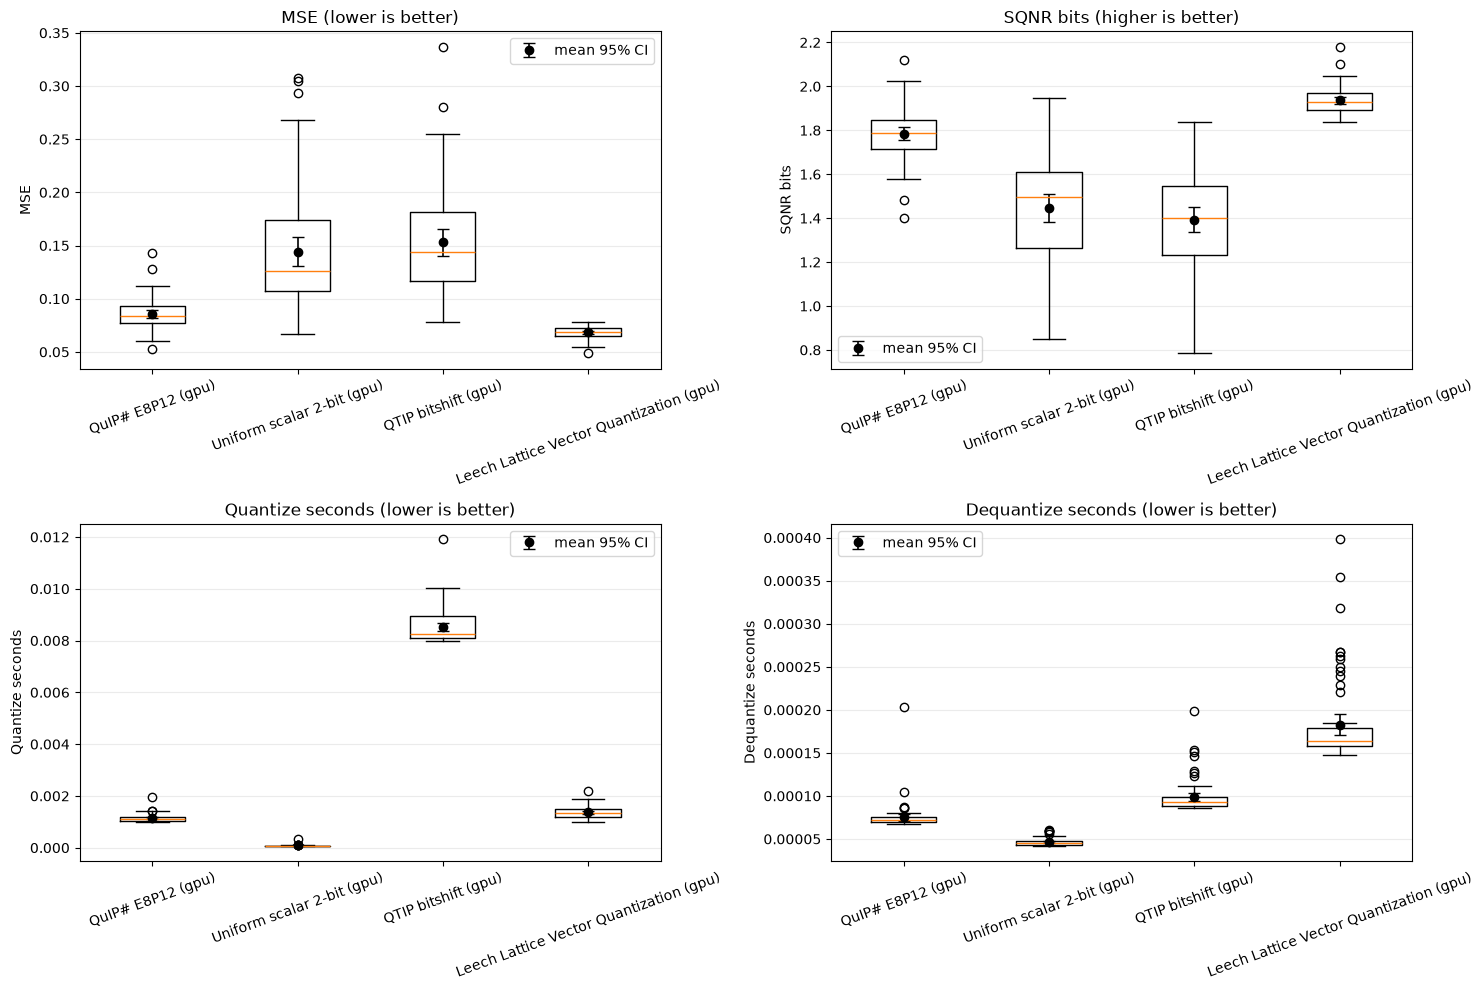

Metric distributions with fitted normal references


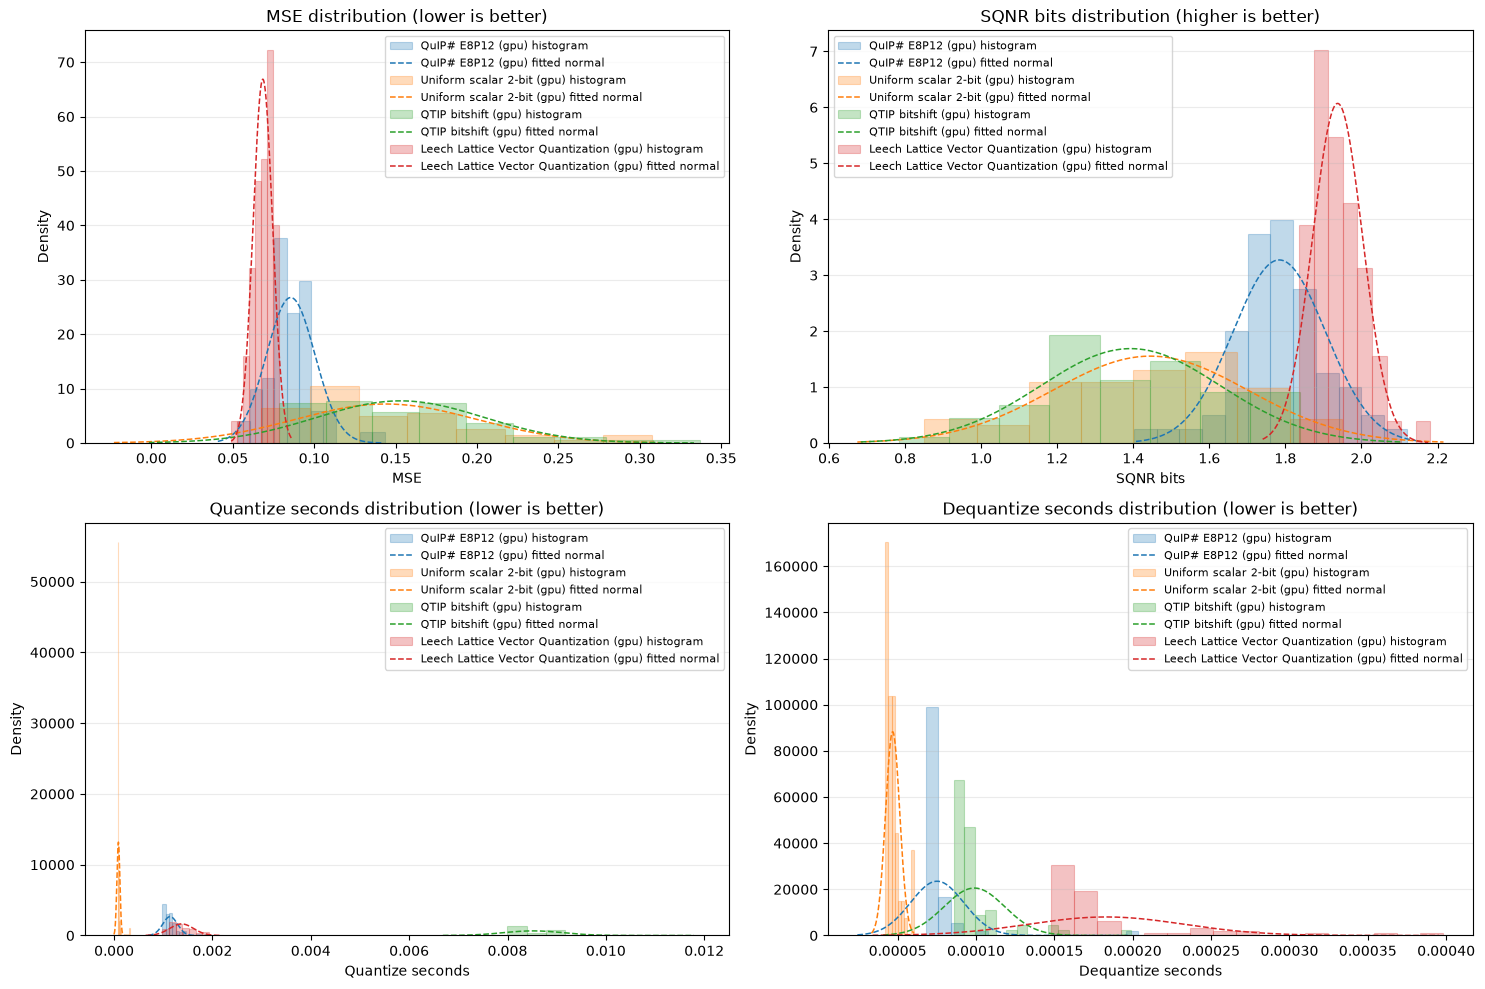

In [40]:
print("Metric boxplots with mean 95% confidence intervals")
metric_boxplot_figure = plot_metric_boxplots_with_ci(FINAL_CSV, final_data_statistics)
plt.show()
print("Metric distributions with fitted normal references")
metric_distribution_figure = plot_metric_distributions_with_normal_reference(FINAL_CSV)
plt.show()


Normality progression summary


,metric,sample_unit,first_passing_n,largest_passing_n,full_n,full_n_p_value,alpha,passes_at_full_n
0,sqnr_bits,vectors,5.0,67.0,67,8.388632e-01,0.05,True
1,quantize_seconds,timing_repeats,5.0,30.0,67,1.033355e-16,0.05,False
2,dequantize_seconds,timing_repeats,NaN,NaN,67,2.323671e-18,0.05,False


Normality progression by sample size


,metric,sample_unit,n_blocks,n_residuals,test,statistic,p_value,alpha,passes_alpha,note
0,sqnr_bits,vectors,5,20,shapiro_wilk,0.944245,2.880334e-01,0.05,True,ok
1,sqnr_bits,vectors,10,40,shapiro_wilk,0.979924,6.867205e-01,0.05,True,ok
2,sqnr_bits,vectors,15,60,shapiro_wilk,0.992404,9.717187e-01,0.05,True,ok
3,sqnr_bits,vectors,20,80,shapiro_wilk,0.992567,9.298331e-01,0.05,True,ok
4,sqnr_bits,vectors,25,100,shapiro_wilk,0.991487,7.829066e-01,0.05,True,ok
5,sqnr_bits,vectors,30,120,shapiro_wilk,0.992130,7.332628e-01,0.05,True,ok
6,sqnr_bits,vectors,40,160,shapiro_wilk,0.993293,6.692690e-01,0.05,True,ok
7,sqnr_bits,vectors,50,200,shapiro_wilk,0.994211,6.319950e-01,0.05,True,ok
8,sqnr_bits,vectors,60,240,shapiro_wilk,0.996551,8.795104e-01,0.05,True,ok
9,sqnr_bits,vectors,67,268,shapiro_wilk,0.996606,8.388632e-01,0.05,True,ok


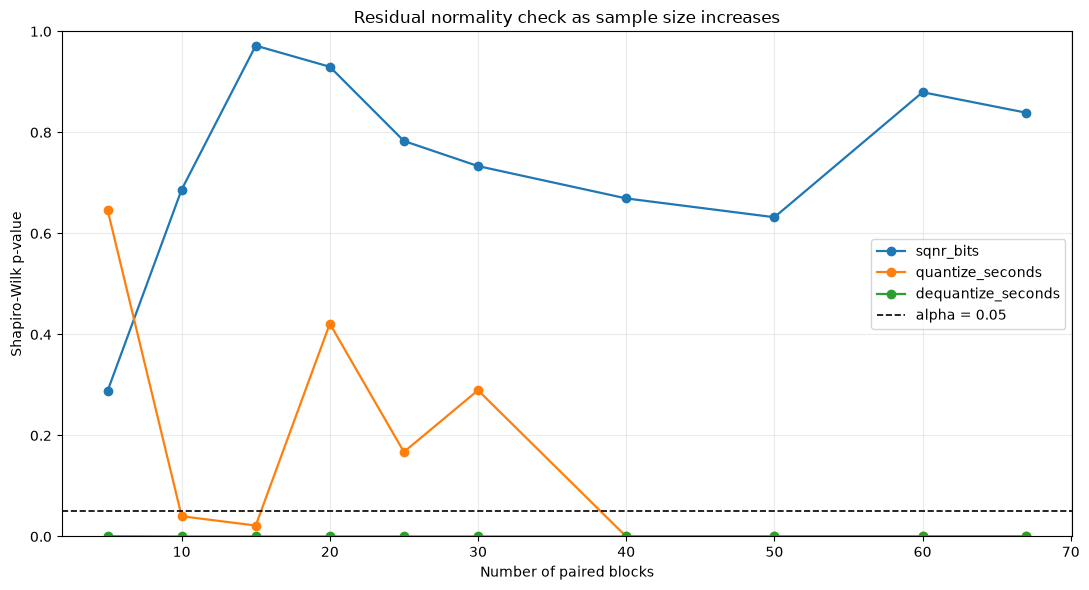

In [41]:
normality_vs_n_table = normality_progression_table(metric_samples, alpha=ALPHA)
normality_vs_n_summary = normality_progression_summary(normality_vs_n_table)
print("Normality progression summary")
display(normality_vs_n_summary)
print("Normality progression by sample size")
display(normality_vs_n_table)
normality_vs_n_figure = plot_normality_progression(normality_vs_n_table)
plt.show()


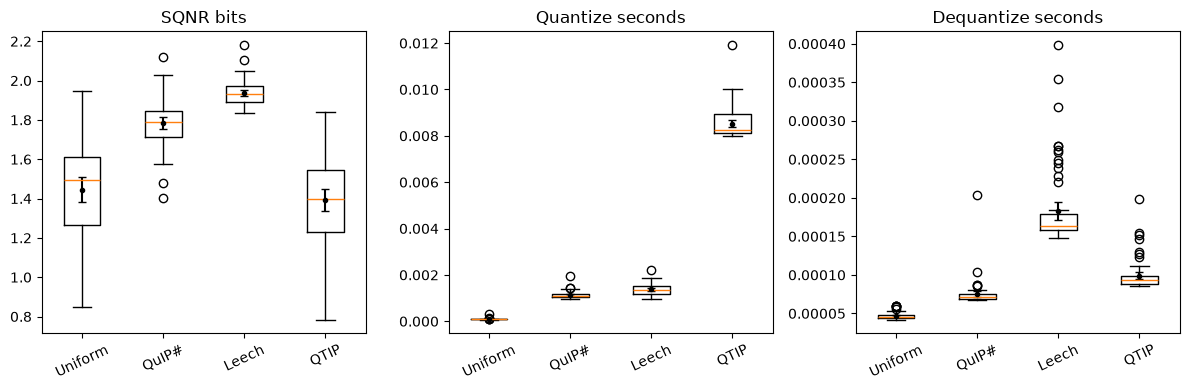

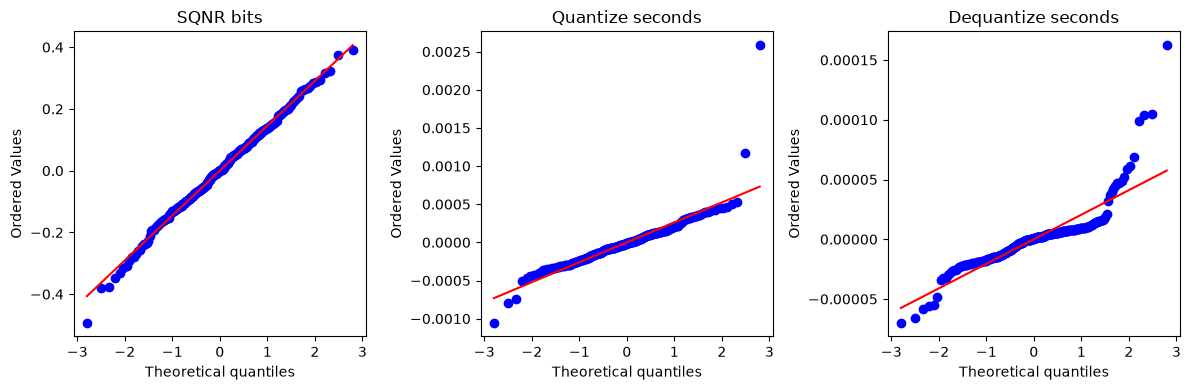

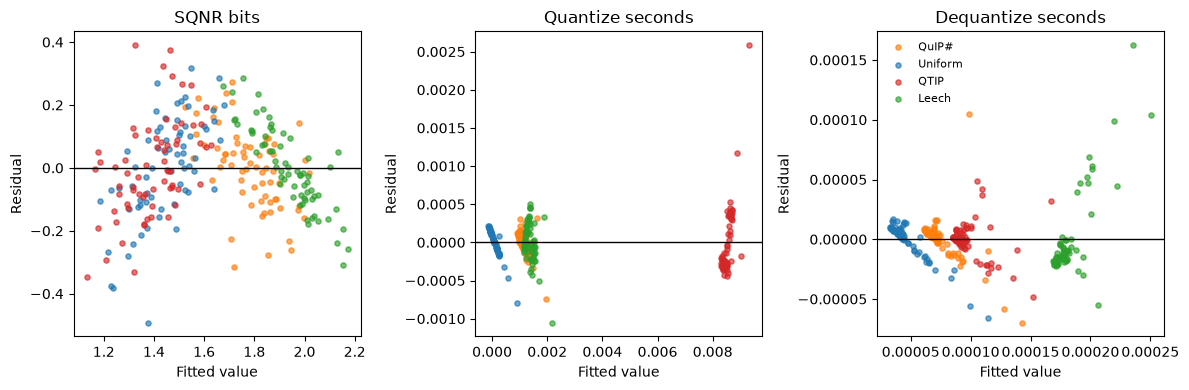

In [42]:
# Optional: save the three figures used by the LaTeX report from the current final CSV.
method_order = ["Uniform scalar 2-bit (gpu)", "QuIP# E8P12 (gpu)", "Leech Lattice Vector Quantization (gpu)", "QTIP bitshift (gpu)"]
short_names = ["Uniform", "QuIP#", "Leech", "QTIP"]
report_metrics = [("sqnr_bits", "SQNR bits"), ("quantize_seconds", "Quantize seconds"), ("dequantize_seconds", "Dequantize seconds")]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (metric, label) in zip(axes, report_metrics):
    data = [final_df[final_df["method"].eq(method)][metric].to_numpy() for method in method_order]
    ax.boxplot(data, tick_labels=short_names, showfliers=True)
    for i, values in enumerate(data, start=1):
        n = len(values)
        mean = float(np.mean(values))
        ci = float(stats.t.ppf(0.975, n - 1) * np.std(values, ddof=1) / math.sqrt(n))
        ax.errorbar(i, mean, yerr=ci, fmt="ko", markersize=3, capsize=3)
    ax.set_title(label)
    ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(REPORT_ASSETS_DIR / "final_metric_boxplots.pdf", bbox_inches="tight")
fig.savefig(REPORT_ASSETS_DIR / "final_metric_boxplots.png", dpi=200, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (metric, label) in zip(axes, report_metrics):
    residuals = repeated_measures_residuals(metric_samples[metric]["samples"])
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title(label)
fig.tight_layout()
fig.savefig(REPORT_ASSETS_DIR / "shapiro_residual_qq_plots.pdf", bbox_inches="tight")
fig.savefig(REPORT_ASSETS_DIR / "shapiro_residual_qq_plots.png", dpi=200, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
method_colors = {
    "Uniform scalar 2-bit (gpu)": "#1f77b4",
    "QuIP# E8P12 (gpu)": "#ff7f0e",
    "Leech Lattice Vector Quantization (gpu)": "#2ca02c",
    "QTIP bitshift (gpu)": "#d62728",
}
method_labels = {
    "Uniform scalar 2-bit (gpu)": "Uniform",
    "QuIP# E8P12 (gpu)": "QuIP#",
    "Leech Lattice Vector Quantization (gpu)": "Leech",
    "QTIP bitshift (gpu)": "QTIP",
}
for ax, (metric, label) in zip(axes, report_metrics):
    names, y = sample_matrix(metric_samples[metric]["samples"])
    grand = np.mean(y)
    fitted = np.mean(y, axis=1, keepdims=True) + np.mean(y, axis=0, keepdims=True) - grand
    residuals = y - fitted
    for idx, name in enumerate(names):
        ax.scatter(
            fitted[:, idx],
            residuals[:, idx],
            s=14,
            alpha=0.65,
            color=method_colors.get(name),
            label=method_labels.get(name, name),
        )
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(label)
    ax.set_xlabel("Fitted value")
    ax.set_ylabel("Residual")
axes[-1].legend(loc="best", fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(REPORT_ASSETS_DIR / "homoscedasticity_residuals_vs_fitted.pdf", bbox_inches="tight")
fig.savefig(REPORT_ASSETS_DIR / "homoscedasticity_residuals_vs_fitted.png", dpi=200, bbox_inches="tight")
plt.show()
